# Unsupervised Learning - Clustering

### 1. Import required libraries and Load the Reduced Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_reduced_dataset.csv to heart_disease_reduced_dataset.csv


In [4]:
df = pd.read_csv('heart_disease_reduced_dataset.csv')

In [5]:
df.head()

,PC13,PC5,PC9,PC2,PC12,PC11,PC15,PC1,HeartDisease
0,0.174570,2.767598,-0.012057,2.262340,0.723671,0.567220,0.386863,0.684512,0
1,-0.340249,0.017665,-0.204954,1.260364,0.444649,-0.771801,-0.856000,3.570333,2
2,-0.313430,-0.740147,-1.090397,-0.713093,-0.406428,0.148344,-0.251198,3.402447,1
3,1.884434,0.317091,-0.740746,0.220787,0.964626,0.203725,-0.828009,-1.651317,0
4,0.631125,1.199871,0.087860,-0.457629,-1.421694,0.696152,0.302566,-2.501824,0


### 2. Split the dataset

In [6]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

### 3. K-Means Clustering

* Elbow method to find optimal K

In [7]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

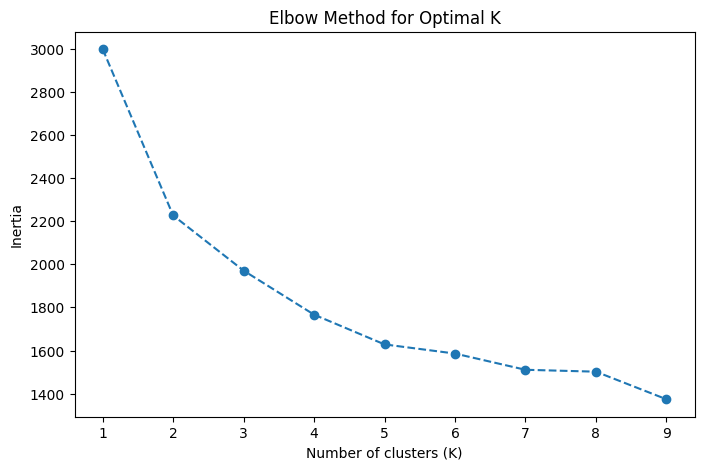

In [8]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [9]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

* Visualize K-Means clusters (using first 2 PCs for plotting)

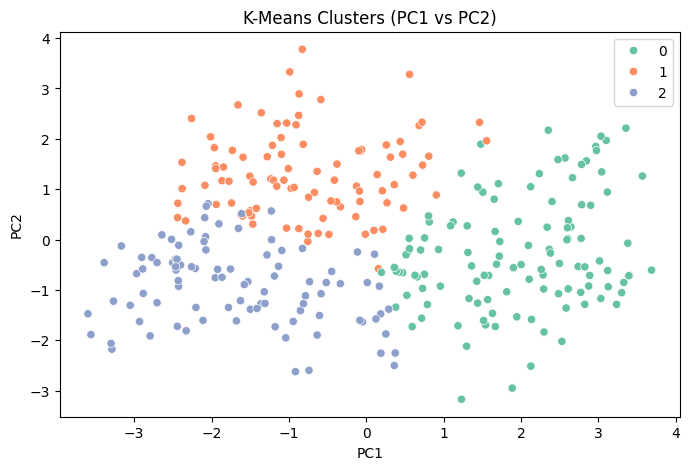

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X["PC1"], y=X["PC2"], hue=kmeans_labels, palette="Set2")
plt.title("K-Means Clusters (PC1 vs PC2)")
plt.show()


* Compare The K-Means Clusters with actual labels

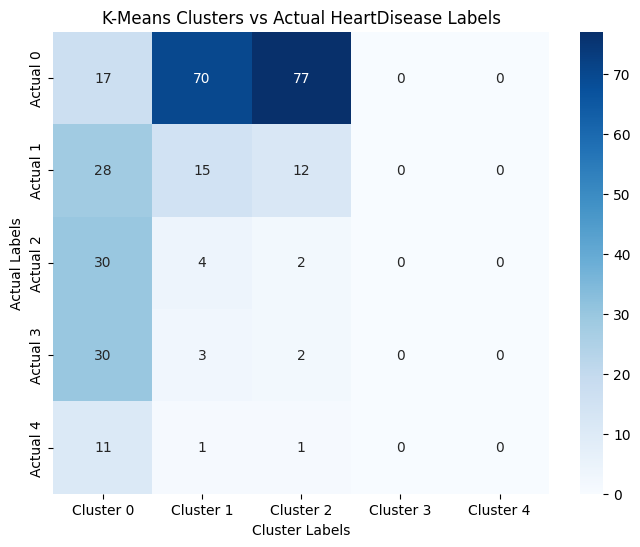

In [16]:
cm = confusion_matrix(y, kmeans_labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {i}" for i in sorted(y.unique())],
                     columns=[f"Cluster {i}" for i in range(cm.shape[1])])

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("K-Means Clusters vs Actual HeartDisease Labels")
plt.ylabel("Actual Labels")
plt.xlabel("Cluster Labels")
plt.show()

In [13]:
print(classification_report(y, kmeans_labels))

              precision    recall  f1-score   support

           0       0.15      0.10      0.12       164
           1       0.16      0.27      0.20        55
           2       0.02      0.06      0.03        36
           3       0.00      0.00      0.00        35
           4       0.00      0.00      0.00        13

    accuracy                           0.11       303
   macro avg       0.07      0.09      0.07       303
weighted avg       0.11      0.11      0.11       303



### 4. Hierarchical Clustering

* Plot dendrogram

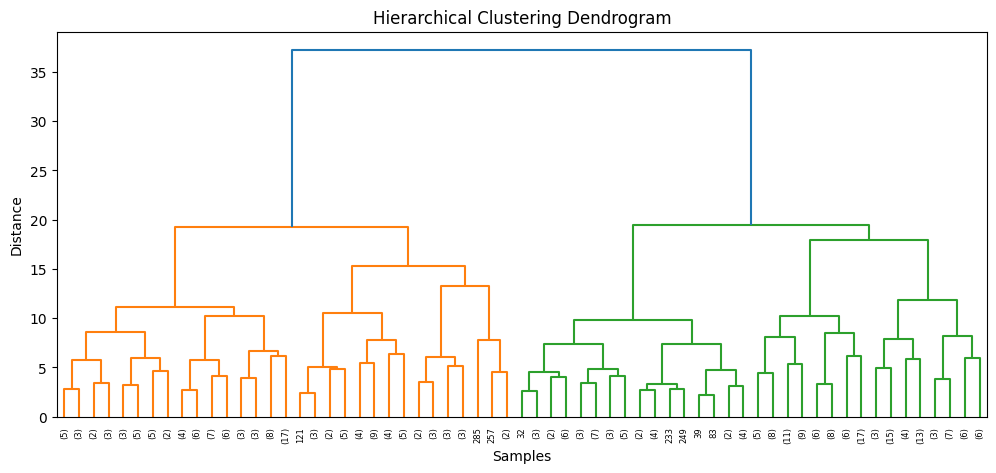

In [17]:
linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(12,5))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

* Form flat clusters

In [18]:
hier_labels = fcluster(linkage_matrix, t=k_optimal, criterion='maxclust')

* Visualize Hierarchical clusters

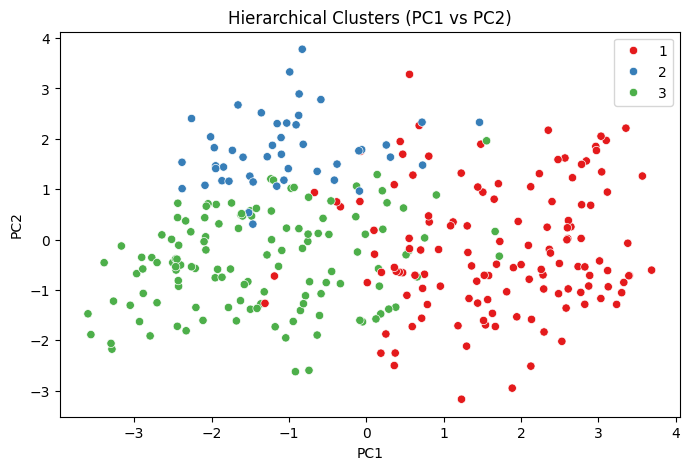

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X["PC1"], y=X["PC2"], hue=hier_labels, palette="Set1")
plt.title("Hierarchical Clusters (PC1 vs PC2)")
plt.show()

* Compare The Hierarchical Clusters with Actual labels

In [20]:
cm_hier = confusion_matrix(y, hier_labels)
cm_hier_df = pd.DataFrame(cm_hier, index=[f"Actual {i}" for i in sorted(y.unique())],
                          columns=[f"Cluster {i}" for i in range(cm_hier.shape[1])])

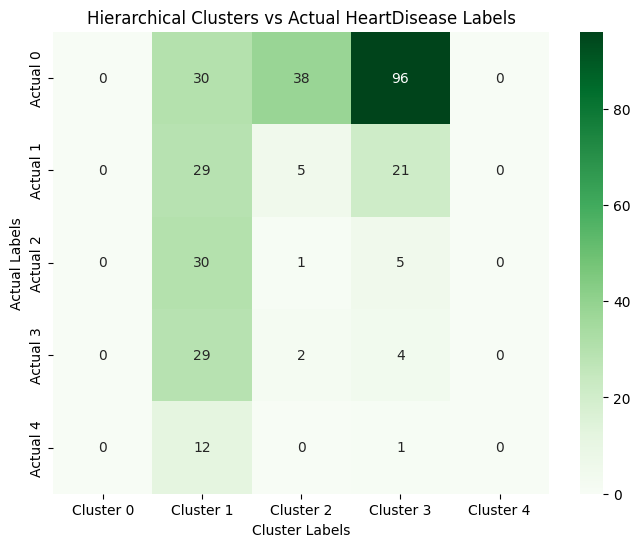

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_hier_df, annot=True, fmt="d", cmap="Greens")
plt.title("Hierarchical Clusters vs Actual HeartDisease Labels")
plt.ylabel("Actual Labels")
plt.xlabel("Cluster Labels")
plt.show()

In [22]:
print(classification_report(y, hier_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       164
           1       0.22      0.53      0.31        55
           2       0.02      0.03      0.02        36
           3       0.03      0.11      0.05        35
           4       0.00      0.00      0.00        13

    accuracy                           0.11       303
   macro avg       0.06      0.13      0.08       303
weighted avg       0.05      0.11      0.07       303



# End of this file, go to ->  06_hyperparameter_tuning.ipynb